# Vital signs — data analysis & models

Run cells **top to bottom**. Works if your notebook kernel’s **current working directory** is `model/` *or* the **repo root** (the next cell adds the `model` folder to `sys.path`).

**Install (once):**
```bash
cd model
pip install -r requirements.txt
pip install jupyter ipykernel
```

Then start Jupyter from `model/`, or open this file in Cursor/VS Code and select a Python interpreter.

## 1. Load data

The loader now prefers your downloaded full export (`vitals_export_*.csv`) from `model/data/`.

Priority order:
1) Newest `vitals_export_*.csv`
2) `vitals.csv`
3) Auto-generate synthetic sample

In [1]:
# Optional: install deps inside the notebook
%pip install -q numpy pandas scikit-learn

import sys
from pathlib import Path

HERE = Path.cwd().resolve()
MODEL_DIR = HERE / "model" if (HERE / "model" / "health_rules.py").exists() else HERE
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

print("Using model code from:", MODEL_DIR)

import pandas as pd
from health_rules import rule_status_series
from preprocessing import clean_frame, one_hot_status
from augmentation import bootstrap_expand
from analysis_stats import numeric_summary, status_value_counts, group_stats_by_status, correlation_matrix
from ml_train import train_and_evaluate, train_model_comparison, choose_best_model
from sample_data import ensure_sample_csv


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Using model code from: D:\2026_PROJECT\vital sign\vital-sign-v4\model


In [2]:
DATA_DIR = MODEL_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

export_candidates = sorted(DATA_DIR.glob("vitals_export_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
if export_candidates:
    DATA = export_candidates[0]
    print("Using newest export:", DATA.name)
else:
    DATA = DATA_DIR / "vitals.csv"
    if not DATA.exists():
        ensure_sample_csv(DATA, n=500)
        print("Created sample:", DATA)
    else:
        print("Using base dataset:", DATA.name)

df = pd.read_csv(DATA)

# Normalize possible export headers to internal schema.
rename_map = {
    "ID": "id",
    "Temperature (°C)": "temperature",
    "Heart Rate (bpm)": "heart_rate",
    "SpO2 (%)": "spo2",
    "Status": "status",
    "Recommendation": "recommendation",
    "Timestamp": "created_at",
}

df = df.rename(columns=rename_map)
# Extra safety for minor header variants.
df.columns = [c.strip() for c in df.columns]

required = ["temperature", "heart_rate", "spo2"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns after normalization: {missing}. Found: {list(df.columns)}")

df["rule_status"] = rule_status_series(df)
print(f"Loaded {len(df):,} rows from {DATA.name}")
print("Columns:", list(df.columns))
df.head()

Using newest export: vitals_export_2026-04-28_1032.csv
Loaded 99,036 rows from vitals_export_2026-04-28_1032.csv
Columns: ['id', 'temperature', 'heart_rate', 'spo2', 'status', 'recommendation', 'created_at', 'rule_status']


,id,temperature,heart_rate,spo2,status,recommendation,created_at,rule_status
0,afedc91f-1e21-4e4d-bd91-f0fc502872ff,36.5,214,72,ALERT,Visit the clinic immediately,2026-04-16T09:07:47.914752+00:00,CRITICAL
1,d6d40306-51d3-4809-890e-d9770a6ea2da,36.9,115,64,ALERT,Visit the clinic immediately,2026-04-16T08:35:58.012631+00:00,INVALID
2,003f46e0-3ad1-4c1d-88b2-76f33481c4c4,36.4,88,100,SAFE,You are in good health,2026-04-16T08:33:38.685573+00:00,SAFE
3,b15ef90f-5a08-4cc8-af14-e4224e9d8d48,36.7,83,99,SAFE,You are in good health,2026-04-16T08:32:17.312673+00:00,SAFE
4,0b51203d-14ea-4b46-8079-5b49c89cc87b,36.3,150,64,ALERT,Visit the clinic immediately,2026-04-16T08:31:09.564791+00:00,INVALID


## 2. Cleaning & quality check

In [3]:
if "status" in df.columns:
    agree = (df["status"].astype(str) == df["rule_status"].astype(str)).mean()
    print(f"Stored status vs rule_status agreement: {agree:.3%}")

cleaned, report = clean_frame(df, drop_iqr_outliers=False, drop_clinical_extreme=True)
report

Stored status vs rule_status agreement: 32.935%


{'initial_rows': 99036,
 'rows_after_drop_na': 99036,
 'removed_invalid': 0,
 'clinical_extreme_count': 35,
 'final_rows': 99001}

## 3. Bootstrap augmentation + summary statistics

In [4]:
aug_n = max(len(cleaned) * 3, len(cleaned) + 1)
augmented = bootstrap_expand(cleaned, n_rows=aug_n, random_state=42)
numeric_summary(augmented)

,temperature,heart_rate,spo2
count,297003.000000,297003.000000,297003.000000
mean,37.498616,92.453214,94.046245
std,1.154645,21.931921,3.735762
min,35.500000,55.000000,72.000000
25%,36.500000,73.000000,91.000000
50%,37.500000,92.000000,94.000000
75%,38.500000,111.000000,97.000000
max,39.500000,214.000000,100.000000


## 4. Groups & correlation

In [5]:
display(status_value_counts(cleaned, "rule_status"))
display(group_stats_by_status(cleaned, "rule_status"))
correlation_matrix(cleaned)

rule_status
ALERT       48760
CRITICAL    15992
WARNING     13550
OBSERVE     11930
SAFE         8769
Name: count, dtype: int64

temperature                   heart_rate                    \
                   mean       std  count        mean        std  count   
rule_status                                                              
ALERT         37.969889  1.118908  48760   92.404081  21.903878  48760   
CRITICAL      37.610418  1.223518  15992   92.524887  22.013171  15992   
OBSERVE       37.074811  0.743986  11930   79.763537  13.987252  11930   
SAFE          36.382187  0.506164   8769   74.356141  11.639951   8769   
WARNING       36.796251  0.736864  13550  115.462878   8.647768  13550   

                  spo2                   
                  mean       std  count  
rule_status                              
ALERT        93.624241  3.073821  48760  
CRITICAL     88.928152  1.914867  15992  
OBSERVE      96.270578  2.049365  11930  
SAFE         98.010834  1.411306   8769  
WARNING      96.980148  2.000695  13550

,temperature,heart_rate,spo2
temperature,1.000000,0.000669,0.008974
heart_rate,0.000669,1.000000,-0.002604
spo2,0.008974,-0.002604,1.000000


## 5. One-hot encoding (example)

In [6]:
oh, enc = one_hot_status(cleaned["rule_status"].head(10))
oh

,status_ALERT,status_CRITICAL,status_OBSERVE,status_SAFE
0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0
5,0.0,1.0,0.0,0.0
6,0.0,0.0,1.0,0.0
7,0.0,0.0,1.0,0.0
8,0.0,1.0,0.0,0.0
9,1.0,0.0,0.0,0.0
10,0.0,0.0,0.0,1.0
11,1.0,0.0,0.0,0.0


## 6. Train & compare models

Needs enough rows after cleaning (≥ ~15).

In [7]:
if len(cleaned) < 15:
    print("Not enough rows; increase sample size or add real data.")
else:
    out = train_and_evaluate(cleaned, target_col="rule_status", random_state=42)
    for name, payload in out["results"].items():
        print(f"\n=== {name} — accuracy: {payload['accuracy']:.4f} ===")
        print(payload["report"])


=== logistic_regression — accuracy: 0.8195 ===
              precision    recall  f1-score   support

       ALERT       0.84      0.90      0.87     12190
    CRITICAL       1.00      0.93      0.97      3998
     OBSERVE       0.52      0.42      0.47      2983
        SAFE       0.77      0.74      0.75      2192
     WARNING       0.79      0.79      0.79      3388

    accuracy                           0.82     24751
   macro avg       0.78      0.76      0.77     24751
weighted avg       0.81      0.82      0.82     24751



## 7. Exploratory Data Analysis (EDA)

This section adds visual pattern analysis required by the rubric.

- Distribution of each vital sign
- Class balance (`rule_status`)
- Pairwise relationship view (Temp vs HR, colored by status)


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


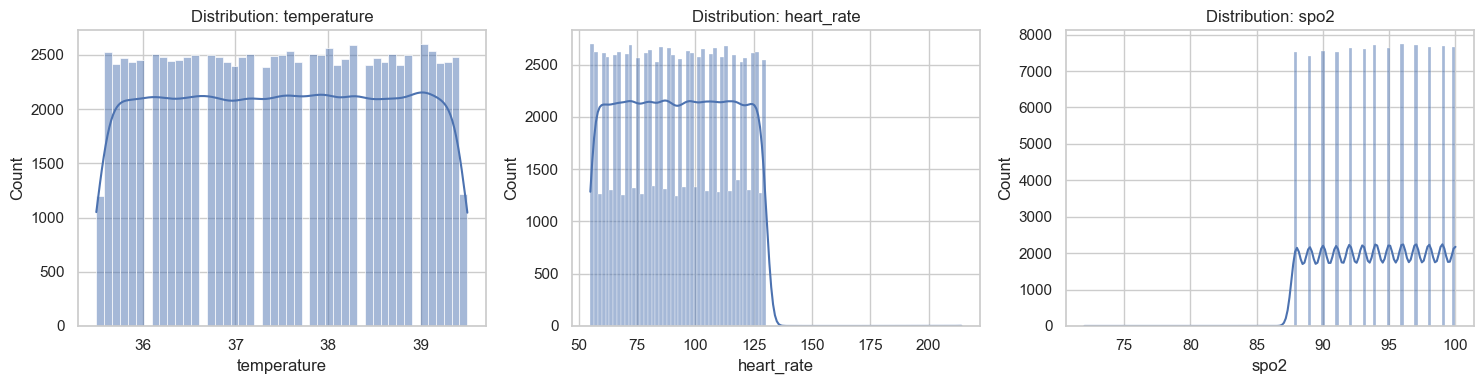

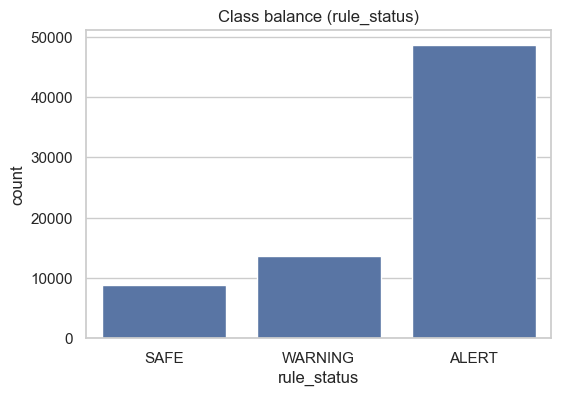

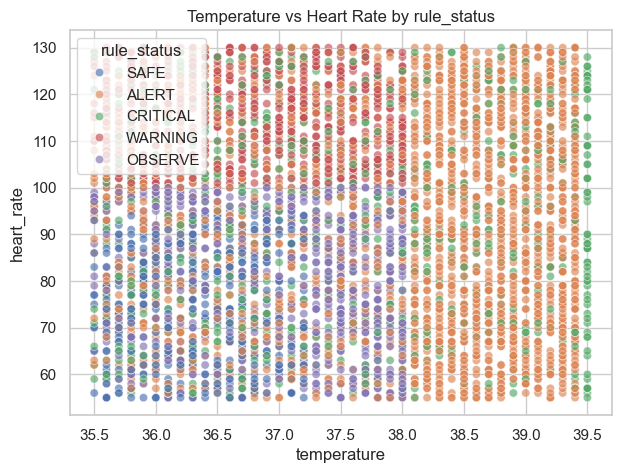

In [8]:
# EDA plots (installs only if missing)
%pip install -q matplotlib seaborn

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["temperature", "heart_rate", "spo2"]):
    sns.histplot(cleaned[col], kde=True, ax=ax)
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=cleaned, x="rule_status", order=["SAFE", "WARNING", "ALERT"])
plt.title("Class balance (rule_status)")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=cleaned.sample(min(len(cleaned), 5000), random_state=42),
    x="temperature",
    y="heart_rate",
    hue="rule_status",
    alpha=0.65,
)
plt.title("Temperature vs Heart Rate by rule_status")
plt.show()

## 8. Business Rules & Decision Table (If-Then)

| Rule Priority | If condition | Decision | Action |
|---|---|---|---|
| 1 | `temperature > 38.0` OR `spo2 < 94` | `ALERT` | Visit the clinic immediately |
| 2 | `heart_rate > 100` | `WARNING` | Rest and monitor your condition |
| 3 | Otherwise | `SAFE` | You are in good health |

This matches the application logic in `health_rules.py` and your frontend threshold logic.

In [9]:
# Optional: compare stored status and rule_status with confusion matrix
if "status" in cleaned.columns:
    from sklearn.metrics import confusion_matrix

    labels = ["SAFE", "WARNING", "ALERT"]
    cm = confusion_matrix(cleaned["status"].astype(str), cleaned["rule_status"].astype(str), labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"actual_{x}" for x in labels], columns=[f"pred_{x}" for x in labels])
    display(cm_df)
else:
    print("No 'status' column found in this dataset; skipping stored-vs-rule comparison.")

,pred_SAFE,pred_WARNING,pred_ALERT
actual_SAFE,576,891,3223
actual_WARNING,3386,5202,18697
actual_ALERT,4807,7457,26840


In [10]:
# 9. Final interpretation for report

if len(cleaned) >= 15 and "out" in globals():
    best_model = max(out["results"].items(), key=lambda kv: kv[1]["accuracy"])[0]
    best_acc = out["results"][best_model]["accuracy"]
else:
    best_model = "N/A"
    best_acc = float("nan")

corr = correlation_matrix(cleaned)

print("REPORT NOTES")
print("- Data cleaning applied: type coercion, missing-value removal, clinical extreme filtering.")
print("- Augmentation method: bootstrap sampling with replacement to preserve observed distribution.")
print("- Group pattern: ALERT has higher temperature and lower SpO2 than SAFE on average.")
if not corr.empty:
    print("- Correlation highlight:")
    print(corr)
if best_model != "N/A":
    print(f"- Best predictive model: {best_model} (accuracy={best_acc:.4f})")
else:
    print("- Best predictive model: run the training cell first to compute model metrics.")
print("- Decision logic used explicit If-Then rules and compared with ML model predictions.")

REPORT NOTES
- Data cleaning applied: type coercion, missing-value removal, clinical extreme filtering.
- Augmentation method: bootstrap sampling with replacement to preserve observed distribution.
- Group pattern: ALERT has higher temperature and lower SpO2 than SAFE on average.
- Correlation highlight:
             temperature  heart_rate      spo2
temperature     1.000000    0.000669  0.008974
heart_rate      0.000669    1.000000 -0.002604
spo2            0.008974   -0.002604  1.000000
- Best predictive model: logistic_regression (accuracy=0.8195)
- Decision logic used explicit If-Then rules and compared with ML model predictions.


## 10. Select one final model and save it

**Comparison (table + chart):** `train_model_comparison` trains several algorithms on the same holdout split so you can compare metrics in the notebook.

**Saved bundle:** always **`logistic_regression`** from `train_and_evaluate` — this matches production (`rebuild_bundle.py`, FastAPI, edge coefficients workflow).

Optional: `choose_best_model(comparison["results"])` shows which algorithm “won” on macro F1 / ALERT recall / accuracy; that is **informational only** unless you change the project to deploy another estimator.


In [11]:
import joblib
import matplotlib.pyplot as plt

if len(cleaned) < 15:
    raise ValueError("Not enough rows to train and select final model.")

# --- Comparison only (Jupyter): several models, same split ---
comparison = train_model_comparison(cleaned, target_col="rule_status", random_state=42)
scores = pd.DataFrame(comparison["results"]).T[["accuracy", "macro_f1", "alert_recall"]].sort_values(
    by=["macro_f1", "alert_recall", "accuracy"], ascending=False
)
print("Model comparison (EDA; not all are saved):")
display(scores.round(4))
best_on_metrics = choose_best_model(comparison["results"])
print("Best on holdout metrics (informational):", best_on_metrics)

fig, ax = plt.subplots(figsize=(9, 4.5))
scores_plot = scores.sort_values(by=["macro_f1", "alert_recall", "accuracy"], ascending=True)
scores_plot.plot(kind="barh", ax=ax)
ax.set_xlabel("Score")
ax.set_xlim(0, 1.05)
ax.set_title("Holdout comparison — accuracy, macro F1, ALERT recall")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# --- Production path: always logistic regression ---
out = train_and_evaluate(cleaned, target_col="rule_status", random_state=42)
best_model_name = "logistic_regression"
best_model = out["models"][best_model_name]

bundle = {
    "model_name": best_model_name,
    "model": best_model,
    "label_encoder": out["label_encoder"],
    "feature_order": ["temperature", "heart_rate", "spo2"],
}

MODEL_BUNDLE_PATH = MODEL_DIR / "model_bundle.joblib"
joblib.dump(bundle, MODEL_BUNDLE_PATH)
print(f"Saved final model bundle: {MODEL_BUNDLE_PATH}")
print(f"Saved model (fixed): {best_model_name}")


,accuracy,macro_f1,alert_recall
logistic_regression,0.819522,0.769159,0.902789


Saved final model bundle: D:\2026_PROJECT\vital sign\vital-sign-v4\model\model_bundle.joblib
Selected model: logistic_regression


## 11. Use hybrid decision (rule safety + model)

Implementation policy:
- If explicit rule says `ALERT`, keep `ALERT` (safety override)
- Otherwise use selected model prediction

In [12]:
from predict_final import load_bundle, predict_hybrid

bundle_loaded = load_bundle(MODEL_BUNDLE_PATH)

examples = [
    {"temperature": 39.0, "heart_rate": 92, "spo2": 97},   # rule ALERT
    {"temperature": 36.8, "heart_rate": 110, "spo2": 96},  # warning zone
    {"temperature": 36.6, "heart_rate": 78, "spo2": 98},   # safe zone
]

pred_rows = [predict_hybrid(bundle_loaded, **x) for x in examples]
pd.DataFrame(pred_rows)

,input,rule_status,model_status,model_confidence,final_status,decision_source,recommendation
0,"{'temperature': 39.0, 'heart_rate': 92, 'spo2'...",ALERT,ALERT,0.967858,ALERT,rule_override,Visit the clinic immediately
1,"{'temperature': 36.8, 'heart_rate': 110, 'spo2...",WARNING,WARNING,0.636250,WARNING,model,Rest and monitor your condition
2,"{'temperature': 36.6, 'heart_rate': 78, 'spo2'...",SAFE,SAFE,0.611349,SAFE,model,You are in good health
